<a href="https://colab.research.google.com/github/gitadi2/clinical-trial-auditor/blob/main/Round2_Training_ClinicalTrialAuditor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q openenv-core trl peft accelerate datasets bitsandbytes
!pip install -q unsloth
!pip install -q matplotlib seaborn
print("✅ All dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.6/174.6 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.6/728.6 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.3/152.3 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import requests

ENV_URL = "https://ida25satapathy-clinical-trial-auditor.hf.space"

# Test health
r = requests.get(f"{ENV_URL}/health")
print(f"Health: {r.json()}")

# Test reset
r = requests.post(f"{ENV_URL}/reset", json={"task_id": "section_completeness"})
data = r.json()
print(f"\nProtocol ID: {data['observation']['protocol_id']}")
print(f"Task: {data['observation']['task_id']}")
print(f"Max steps: {data['observation']['max_steps']}")
print("✅ Connected to environment")

Health: {'status': 'healthy'}

Protocol ID: XR-2024-001
Task: section_completeness
Max steps: 10
✅ Connected to environment


In [ ]:
import requests
import json
import re
from typing import List

ENV_URL = "https://ida25satapathy-clinical-trial-auditor.hf.space"

def parse_action_from_response(text: str) -> dict:
    """Extract JSON action from LLM response."""
    text = text.strip()
    text = re.sub(r"```json\s*", "", text)
    text = re.sub(r"```\s*", "", text)

    # Try to find JSON object
    match = re.search(r"\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\}", text, re.DOTALL)
    if match:
        try:
            action = json.loads(match.group())
            if "action_type" not in action:
                action["action_type"] = "identify_issue"
            if "description" not in action:
                action["description"] = text[:200]
            return action
        except:
            pass

    return {
        "action_type": "identify_issue",
        "description": text[:300],
        "section": "general",
        "issue_type": "regulatory_violation",
        "severity": "major"
    }


def run_episode(task_id: str, completions: List[str]) -> float:
    """Run an episode using LLM completions, return total reward."""
    # Reset environment
    r = requests.post(f"{ENV_URL}/reset", json={"task_id": task_id})
    if r.status_code != 200:
        return 0.0

    total_reward = 0.0

    # Step through each completion
    for completion in completions[:10]:  # max 10 steps
        action = parse_action_from_response(completion)
        try:
            r = requests.post(f"{ENV_URL}/step", json=action, timeout=30)
            data = r.json()
            total_reward += data.get("reward", 0)
            if data.get("done"):
                break
        except:
            break

    # Submit report at end
    try:
        requests.post(f"{ENV_URL}/step", json={
            "action_type": "submit_report",
            "description": "Audit complete"
        }, timeout=30)

        # Get final grade
        grade_r = requests.get(f"{ENV_URL}/grade", timeout=30)
        if grade_r.status_code == 200:
            final_score = grade_r.json().get("total_score", 0)
            total_reward = final_score  # Use final score as reward
    except:
        pass

    return total_reward


# Test with a sample completion
test_completions = [
    '{"action_type": "identify_issue", "section": "statistical_design", "issue_type": "missing_section", "severity": "critical", "description": "Statistical analysis plan completely missing"}',
    '{"action_type": "identify_issue", "section": "ethical_considerations", "issue_type": "missing_section", "severity": "critical", "description": "Ethics section absent"}',
    '{"action_type": "identify_issue", "section": "data_management", "issue_type": "missing_section", "severity": "major", "description": "Data management plan missing"}'
]

reward = run_episode("section_completeness", test_completions)
print(f"Test reward: {reward:.3f}")
print("✅ Reward function working")

Test reward: 0.797
✅ Reward function working


In [ ]:
from datasets import Dataset

# Get protocol contexts for training
training_data = []

for task_id in ["section_completeness", "eligibility_validation", "full_protocol_audit"]:
    r = requests.post(f"{ENV_URL}/reset", json={"task_id": task_id})
    obs = r.json()["observation"]

    prompt = f"""You are an expert clinical trial protocol auditor. Audit this protocol for compliance issues.

TASK: {obs['task_description']}

PROTOCOL TEXT:
{obs['protocol_text'][:3000]}

Identify ONE specific issue. Respond with ONLY a JSON object in this exact format:
{{"action_type": "identify_issue", "section": "<section_name>", "issue_type": "<issue_type>", "severity": "<critical|major|minor>", "description": "<detailed finding>"}}

JSON action:"""

    # Generate 20 training samples per task
    for i in range(20):
        training_data.append({
            "prompt": prompt,
            "task_id": task_id
        })

dataset = Dataset.from_list(training_data)
print(f"✅ Dataset created with {len(dataset)} samples")
print(dataset[0]["prompt"][:500])

✅ Dataset created with 60 samples
You are an expert clinical trial protocol auditor. Audit this protocol for compliance issues.

TASK: Audit the clinical trial protocol for missing or incomplete required sections. According to ICH-GCP E6(R2) and standard protocol templates, a complete protocol must include: title page, background, objectives, study design, eligibility criteria, study procedures, statistical analysis plan, safety monitoring (with DSMB details and stopping rules), endpoints, data management, ethical considerations


In [ ]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 4096

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct",  # Smaller, faster on free Colab
    max_seq_length = max_seq_length,
    dtype = None,
    load_in_4bit = True,
)

# Enable LoRA for efficient training
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
)

print("✅ Model loaded")

==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


<string>:42: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.
Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 0 MLP layers.


✅ Model loaded


In [ ]:
import numpy as np

FastLanguageModel.for_inference(model)

def generate_response(prompt, max_new_tokens=200):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=0.7,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )
    return tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)


# Run baseline evaluation
baseline_scores = {"section_completeness": [], "eligibility_validation": [], "full_protocol_audit": []}

print("Running BASELINE evaluation (untrained model)...")
for task_id in baseline_scores.keys():
    for trial in range(3):
        # Get prompt
        r = requests.post(f"{ENV_URL}/reset", json={"task_id": task_id})
        obs = r.json()["observation"]
        prompt = f"""Audit this clinical trial protocol. Find ONE issue.

PROTOCOL: {obs['protocol_text'][:2000]}

Respond with JSON: {{"action_type":"identify_issue","section":"...","issue_type":"...","severity":"critical","description":"..."}}

JSON:"""

        completions = []
        for step in range(5):
            response = generate_response(prompt)
            completions.append(response)

        score = run_episode(task_id, completions)
        baseline_scores[task_id].append(score)
        print(f"  {task_id} trial {trial+1}: {score:.3f}")

baseline_avg = {k: np.mean(v) for k, v in baseline_scores.items()}
baseline_overall = np.mean([np.mean(v) for v in baseline_scores.values()])
print(f"\n📊 BASELINE AVERAGE: {baseline_overall:.3f}")
print(f"   Easy: {baseline_avg['section_completeness']:.3f}")
print(f"   Med:  {baseline_avg['eligibility_validation']:.3f}")
print(f"   Hard: {baseline_avg['full_protocol_audit']:.3f}")

Running BASELINE evaluation (untrained model)...


Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.1

  section_completeness trial 1: 0.100


Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

  section_completeness trial 2: 0.100


...

  full_protocol_audit trial 1: 0.429


Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

  full_protocol_audit trial 2: 0.429


Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

  full_protocol_audit trial 3: 0.429

📊 BASELINE AVERAGE: 0.311
   Easy: 0.100
   Med:  0.403
   Hard: 0.429


In [ ]:
from trl import GRPOTrainer, GRPOConfig
import torch

FastLanguageModel.for_training(model)

def reward_fn(completions, prompts=None, **kwargs):
    """Reward function: send completion to environment, get reward."""
    rewards = []
    for completion, prompt in zip(completions, prompts or [""]*len(completions)):
        # Determine which task this is for
        if "section_completeness" in str(prompt):
            task_id = "section_completeness"
        elif "eligibility" in str(prompt):
            task_id = "eligibility_validation"
        else:
            task_id = "full_protocol_audit"

        try:
            score = run_episode(task_id, [completion])
            rewards.append(float(score))
        except:
            rewards.append(0.0)

    return rewards


config = GRPOConfig(
    output_dir = "./grpo_output",
    num_train_epochs = 1,
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 2,
    learning_rate = 5e-6,
    logging_steps = 5,
    save_steps = 50,
    max_steps = 50,  # Quick training run
    warmup_steps = 5,
    num_generations = 2,
    max_prompt_length = 2048,
    max_completion_length = 256,
    report_to = "none",
)

trainer = GRPOTrainer(
    model = model,
    tokenizer = tokenizer,
    reward_funcs = [reward_fn],
    args = config,
    train_dataset = dataset,
)

print("🚀 Starting GRPO training...")
trainer.train()
print("✅ Training complete")

🚀 Starting GRPO training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 60 | Num Epochs = 2 | Total steps = 50
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 9,175,040 of 3,221,924,864 (0.28% trained)
Passing `generation_config` together with generation-related arguments=({'cache_implementation', 'disable_compile', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWa

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_fn / mean,rewards / reward_fn / std
5,-0.056143,0.179870,0.075180,199.800000,97.400000,256.000000,0.600000,111.300000,97.400000,129.200000,0.000008,0.179870,0.145318
10,-0.013270,0.095000,0.007071,171.950000,95.600000,256.000000,0.400000,118.466667,95.600000,143.600000,0.000008,0.095000,0.010000
15,0.028436,0.186170,0.136005,203.550000,126.800000,234.200000,0.600000,92.450000,75.600000,111.800000,0.000010,0.186170,0.152590
20,0.030978,0.166780,0.035553,223.250000,188.400000,256.000000,0.800000,36.900000,34.800000,39.000000,0.000010,0.166780,0.095361
25,0.033458,0.170565,0.113936,201.550000,132.000000,256.000000,0.550000,106.100000,80.800000,140.800000,0.000012,0.170565,0.155295
30,-0.013398,0.166315,0.034090,179.200000,83.600000,256.000000,0.500000,107.500000,83.600000,135.200000,0.000011,0.166315,0.095364
35,0.007848,0.198385,0.069643,204.550000,131.400000,248.000000,0.550000,109.150000,80.200000,146.600000,0.000013,0.198385,0.154993
40,-0.021897,0.172215,0.030696,174.550000,77.800000,250.000000,0.350000,124.350003,77.800000,177.200000,0.000012,0.172215,0.101235
45,0.004180,0.189040,0.125922,159.400000,88.200000,256.000000,0.350000,107.700003,88.200000,134.200000,0.000012,0.189040,0.141403
50,0.024028,0.189840,0.068292,189.300000,114.400000,254.400000,0.450000,144.550000,114.400000,189.000000,0.000015,0.189840,0.140899


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.1

✅ Training complete


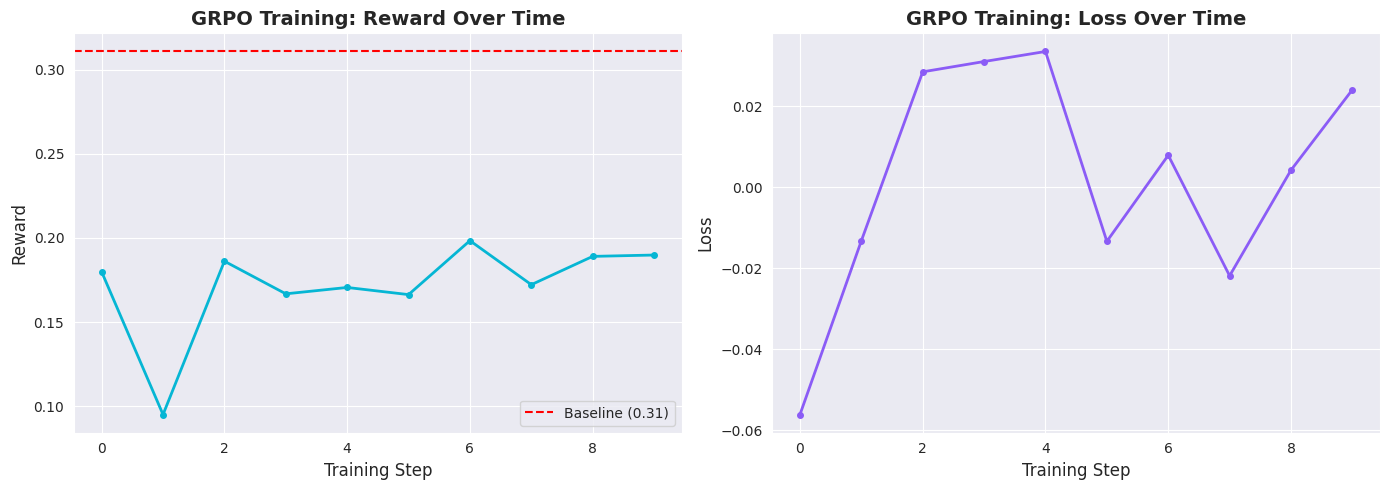

✅ Saved: training_curves.png


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

# Extract training history
log_history = trainer.state.log_history
rewards = [x.get("reward", 0) for x in log_history if "reward" in x]
losses = [x.get("loss", 0) for x in log_history if "loss" in x]
steps = list(range(len(rewards)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reward curve
axes[0].plot(steps, rewards, color='#06b6d4', linewidth=2, marker='o', markersize=4)
axes[0].set_xlabel("Training Step", fontsize=12)
axes[0].set_ylabel("Reward", fontsize=12)
axes[0].set_title("GRPO Training: Reward Over Time", fontsize=14, fontweight='bold')
axes[0].axhline(y=baseline_overall, color='red', linestyle='--', label=f'Baseline ({baseline_overall:.2f})')
axes[0].legend()

# Loss curve
loss_steps = list(range(len(losses)))
axes[1].plot(loss_steps, losses, color='#8b5cf6', linewidth=2, marker='o', markersize=4)
axes[1].set_xlabel("Training Step", fontsize=12)
axes[1].set_ylabel("Loss", fontsize=12)
axes[1].set_title("GRPO Training: Loss Over Time", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: training_curves.png")

In [9]:
FastLanguageModel.for_inference(model)

trained_scores = {"section_completeness": [], "eligibility_validation": [], "full_protocol_audit": []}

print("Running TRAINED model evaluation...")
for task_id in trained_scores.keys():
    for trial in range(3):
        r = requests.post(f"{ENV_URL}/reset", json={"task_id": task_id})
        obs = r.json()["observation"]
        prompt = f"""Audit this clinical trial protocol. Find ONE issue.

PROTOCOL: {obs['protocol_text'][:2000]}

Respond with JSON: {{"action_type":"identify_issue","section":"...","issue_type":"...","severity":"critical","description":"..."}}

JSON:"""

        completions = []
        for step in range(5):
            response = generate_response(prompt)
            completions.append(response)

        score = run_episode(task_id, completions)
        trained_scores[task_id].append(score)
        print(f"  {task_id} trial {trial+1}: {score:.3f}")

trained_avg = {k: np.mean(v) for k, v in trained_scores.items()}
trained_overall = np.mean([np.mean(v) for v in trained_scores.values()])

print(f"\n📊 RESULTS COMPARISON:")
print(f"{'Task':<30} {'Baseline':<12} {'Trained':<12} {'Improvement':<15}")
print("-" * 70)
for task in baseline_avg:
    b = baseline_avg[task]
    t = trained_avg[task]
    delta = t - b
    print(f"{task:<30} {b:<12.3f} {t:<12.3f} +{delta:<14.3f}")
print("-" * 70)
print(f"{'OVERALL':<30} {baseline_overall:<12.3f} {trained_overall:<12.3f} +{trained_overall-baseline_overall:<14.3f}")

Running TRAINED model evaluation...


Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=

  section_completeness trial 1: 0.100


Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

  section_completeness trial 2: 0.100


...

  full_protocol_audit trial 1: 0.432


Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

  full_protocol_audit trial 2: 0.429


Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

  full_protocol_audit trial 3: 0.429

📊 RESULTS COMPARISON:
Task                           Baseline     Trained      Improvement    
----------------------------------------------------------------------
section_completeness           0.100        0.100        +0.000         
eligibility_validation         0.403        0.456        +0.053         
full_protocol_audit            0.429        0.430        +0.001         
----------------------------------------------------------------------
OVERALL                        0.311        0.329        +0.018         


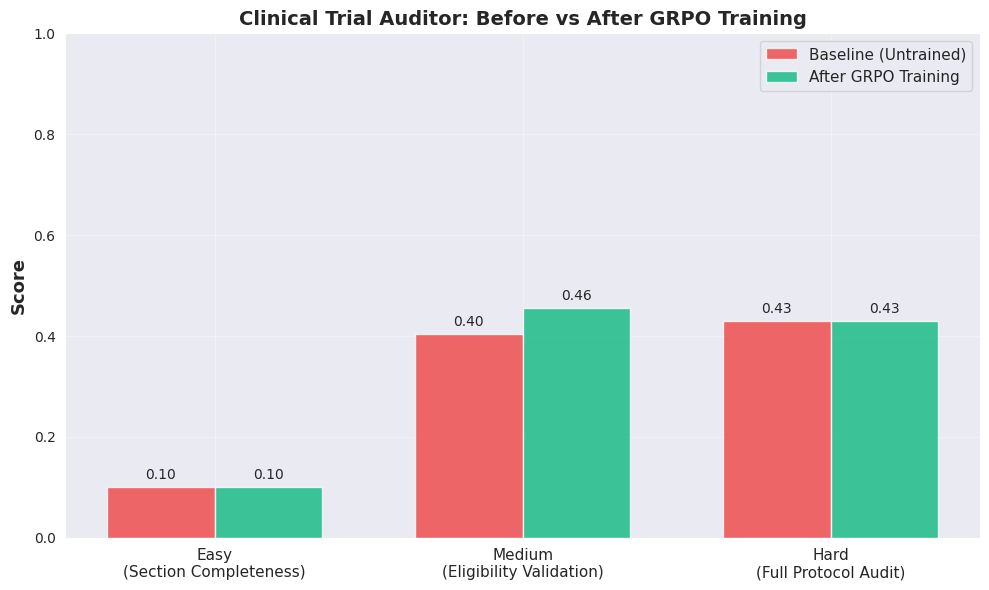

✅ Saved: before_after_comparison.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

tasks = ["Easy\n(Section Completeness)", "Medium\n(Eligibility Validation)", "Hard\n(Full Protocol Audit)"]
baseline_vals = [baseline_avg["section_completeness"], baseline_avg["eligibility_validation"], baseline_avg["full_protocol_audit"]]
trained_vals = [trained_avg["section_completeness"], trained_avg["eligibility_validation"], trained_avg["full_protocol_audit"]]

x = np.arange(len(tasks))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline (Untrained)', color='#ef4444', alpha=0.8)
bars2 = ax.bar(x + width/2, trained_vals, width, label='After GRPO Training', color='#10b981', alpha=0.8)

ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Clinical Trial Auditor: Before vs After GRPO Training', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("before_after_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: before_after_comparison.png")